# Prediction Model
Building a Linear Regression model using technical indicators as features
to predict Apple's closing price. Evaluated on unseen data from 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [7]:
tickers = ["AAPL", "TSLA", "MSFT", "GOOGL", "AMZN"]

stocks = {}

for ticker in tickers:
    stocks[ticker] = pd.read_csv(f"../data/{ticker}.csv", index_col=0, parse_dates=True, skiprows=[1,2])

df = stocks["AAPL"].copy()

# Add all indicators
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()
df["RSI"] = df["Close"].diff().pipe(lambda x: pd.Series(
    100 - (100 / (1 + x.where(x > 0, 0).rolling(14).mean() /
    (-x.where(x < 0, 0).rolling(14).mean()))), index=x.index))
df["EMA_12"] = df["Close"].ewm(span=12).mean()
df["EMA_26"] = df["Close"].ewm(span=26).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["BB_middle"] = df["Close"].rolling(window=20).mean()
df["BB_upper"] = df["BB_middle"] + 2 * df["Close"].rolling(window=20).std()
df["BB_lower"] = df["BB_middle"] - 2 * df["Close"].rolling(window=20).std()

# Drop missing values
df = df.dropna()

print(f"Data shape: {df.shape}")
print("All indicators added!")

Data shape: (1058, 15)
All indicators added!


In [3]:
# Define features (X) and target (y)
features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "BB_upper", "BB_lower"]

X = df[features]
y = df["Close"]

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 846
Testing samples: 212


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [5]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2.28
RMSE: 2.90


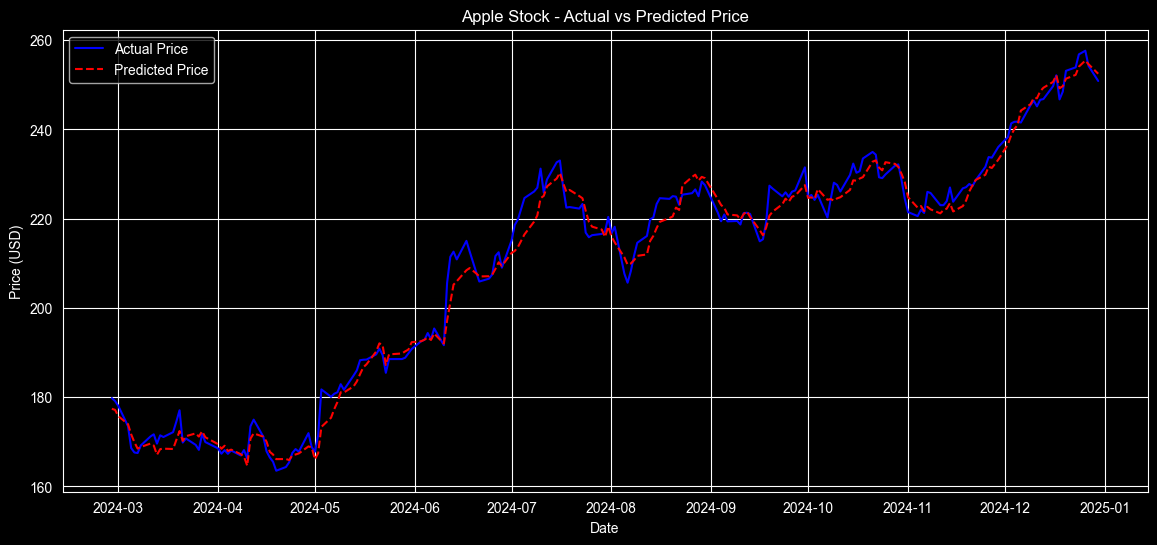

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test.values, label="Actual Price", color="blue")
plt.plot(y_test.index, y_pred, label="Predicted Price", color="red", linestyle="--")

plt.title("Apple Stock - Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()